# Hybrid RAG + DeBERTa Hallucination Detector

```
Input Claim
    |
    |---> FAISS RAG Retriever (all-MiniLM-L6-v2) ---> Top-K Knowledge Docs
    |                                                         |
    +----------------------------(claim, context)-------------+
                                       |
                            DeBERTa-v3-base Encoder
                                       |
                         +-------------+-------------+
                         |                           |
                   Classifier                  NLI Explainer
             (Factual / Hallucinated)    (Why is this hallucinated?)
```

**Improvements over plain BERT:**
- DeBERTa-v3-base beats BERT/RoBERTa on NLI and classification benchmarks
- RAG context fused into classification as (claim, evidence) pair
- NLI entailment engine explains reasoning with retrieved evidence
- All 3 datasets used: train + val combined for maximum coverage
- FP16 + gradient checkpointing for T4 GPU efficiency

> Google Colab: Runtime -> Change runtime type -> T4 GPU

In [2]:
# CELL 1 - Install Dependencies
!pip install -q transformers datasets scikit-learn faiss-cpu sentence-transformers accelerate

import torch, transformers
print(f"PyTorch      : {torch.__version__}")
print(f"Transformers : {transformers.__version__}")
print(f"CUDA         : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")

PyTorch      : 2.10.0+cu128
Transformers : 5.0.0
CUDA         : True
GPU          : Tesla T4


In [26]:
# Cell 2 — Load Data (Kaggle version)

import os
import pandas as pd

# Kaggle dataset path
DATA_DIR = "/kaggle/input/datasets/aaryamanlosalka/dataset"

train_df = pd.read_csv(os.path.join(DATA_DIR, "classification_train.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "classification_validation.csv"))
kb_df    = pd.read_csv(os.path.join(DATA_DIR, "rag_knowledge_base.csv"))

# 🔥 Your exact print style
print(f"Train         : {train_df.shape}")
print(f"Validation    : {val_df.shape}")
print(f"Knowledge Base: {kb_df.shape}")

print("\nLabel distribution (train):")
print(train_df['label'].value_counts())

print("\nKnowledge Base sample:")
print(kb_df.head(3))

Train         : (140000, 3)
Validation    : (10000, 3)
Knowledge Base: (50000, 2)

Label distribution (train):
label
Hallucinated    70049
Factual         69951
Name: count, dtype: int64

Knowledge Base sample:
   id                                           document
0   1  The speed of light in a vacuum is 299,792,458 ...
1   2  Water molecules consist of two hydrogen atoms ...
2   3  The Earth orbits the Sun at an average distanc...


In [4]:
# CELL 3 - Preprocessing: clean, encode labels, combine all data
import numpy as np
from sklearn.model_selection import train_test_split

train_df = train_df.dropna(subset=['text', 'label']).reset_index(drop=True)
val_df   = val_df.dropna(subset=['text', 'label']).reset_index(drop=True)
kb_df    = kb_df.dropna(subset=['document']).reset_index(drop=True)

label_map = {"Factual": 1, "Hallucinated": 0}
train_df['label_id'] = train_df['label'].map(label_map)
val_df['label_id']   = val_df['label'].map(label_map)

# Combine train + val for maximum data, re-split 93/7
all_df = pd.concat([train_df, val_df], ignore_index=True)
train_split, val_split = train_test_split(
    all_df, test_size=0.07, stratify=all_df['label_id'], random_state=42
)
train_split = train_split.reset_index(drop=True)
val_split   = val_split.reset_index(drop=True)

print(f"Combined train : {len(train_split)}")
print(f"Combined val   : {len(val_split)}")
print(f"Knowledge docs : {len(kb_df)}")

Combined train : 139499
Combined val   : 10501
Knowledge docs : 50000


In [5]:
# CELL 4 - Build FAISS Knowledge Base Index
from sentence_transformers import SentenceTransformer
import faiss

print("Loading sentence encoder...")
sentence_encoder = SentenceTransformer('all-MiniLM-L6-v2')

kb_texts = kb_df['document'].tolist()
print(f"Encoding {len(kb_texts)} knowledge base documents...")
kb_embeddings = sentence_encoder.encode(
    kb_texts, batch_size=256, show_progress_bar=True, convert_to_numpy=True
).astype('float32')

dim   = kb_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)   # cosine similarity after L2 normalisation
faiss.normalize_L2(kb_embeddings)
index.add(kb_embeddings)
print(f"FAISS index: {index.ntotal} vectors, dim={dim}")

def retrieve_context(query: str, top_k: int = 3) -> str:
    q_emb = sentence_encoder.encode([query], convert_to_numpy=True).astype('float32')
    faiss.normalize_L2(q_emb)
    _, idxs = index.search(q_emb, top_k)
    docs = [kb_texts[i] for i in idxs[0] if i < len(kb_texts)]
    return " [SEP] ".join(docs)

sample = train_split['text'].iloc[0]
print("\nSample query  :", sample[:80])
print("Retrieved docs :", retrieve_context(sample)[:180])

Loading sentence encoder...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 50000 knowledge base documents...


Batches:   0%|          | 0/196 [00:00<?, ?it/s]

FAISS index: 50000 vectors, dim=384

Sample query  : It has been documented that The Puerto Rico Trench in the Atlantic Ocean is the 
Retrieved docs : The Mariana Trench in the western Pacific Ocean reaches a maximum depth of approximately 11,034 meters at the Challenger Deep, making it the deepest known point on Earth. [SEP] The


In [6]:
# CELL 5 - Pre-compute RAG contexts for train and val sets
from tqdm import tqdm

def batch_retrieve(texts, top_k=3, batch_size=512):
    all_contexts = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Retrieving"):
        batch  = texts[i:i+batch_size]
        q_embs = sentence_encoder.encode(batch, convert_to_numpy=True).astype('float32')
        faiss.normalize_L2(q_embs)
        _, idxs = index.search(q_embs, top_k)
        for row_idxs in idxs:
            docs = [kb_texts[j] for j in row_idxs if j < len(kb_texts)]
            all_contexts.append(" [SEP] ".join(docs))
    return all_contexts

print("Pre-computing train contexts...")
train_split['context'] = batch_retrieve(train_split['text'].tolist())
print("Pre-computing val contexts...")
val_split['context']   = batch_retrieve(val_split['text'].tolist())
print("Done.")

Pre-computing train contexts...


Retrieving: 100%|██████████| 273/273 [01:36<00:00,  2.82it/s]


Pre-computing val contexts...


Retrieving: 100%|██████████| 21/21 [00:07<00:00,  2.83it/s]

Done.


In [7]:
# CELL 6 - Tokenizer (DeBERTa-v3-base)
from transformers import AutoTokenizer

MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LEN    = 256
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_pair(texts, contexts):
    return tokenizer(
        texts, contexts,
        padding='max_length', truncation=True,
        max_length=MAX_LEN, return_tensors='pt'
    )

print("Tokenising train...")
train_enc = tokenize_pair(train_split['text'].tolist(), train_split['context'].tolist())
print("Tokenising val...")
val_enc   = tokenize_pair(val_split['text'].tolist(),   val_split['context'].tolist())
print("Done.")

Tokenising train...
Tokenising val...
Done.


In [8]:
# CELL 7 - PyTorch Dataset
import torch

class HallucinationDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels.tolist()

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = HallucinationDataset(train_enc, train_split['label_id'])
val_dataset   = HallucinationDataset(val_enc,   val_split['label_id'])
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Train: 139499 | Val: 10501


In [9]:
# CELL 8 - Load DeBERTa Model
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label={0: "Hallucinated", 1: "Factual"},
    label2id={"Hallucinated": 0, "Factual": 1},
    ignore_mismatched_sizes=True
)
total_p = sum(p.numel() for p in model.parameters())
print(f"Model: {MODEL_NAME} | Params: {total_p:,}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight        

Model: microsoft/deberta-v3-base | Params: 184,423,682


In [10]:
# CELL 9 - Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import numpy as np

def compute_metrics(pred):
    logits, labels = pred
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=1).numpy()
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    try:
        auc = roc_auc_score(labels, probs[:, 1])
    except Exception:
        auc = 0.0
    return {
        "accuracy" : round(float(acc), 4),
        "f1"       : round(float(f1), 4),
        "precision": round(float(precision), 4),
        "recall"   : round(float(recall), 4),
        "roc_auc"  : round(float(auc), 4)
    }

In [11]:
# CELL 10 - Training Arguments (Colab T4 optimised)
from transformers import TrainingArguments

SAVE_DIR = "/content/drive/MyDrive/hallucination_model"

training_args = TrainingArguments(
    output_dir                  = SAVE_DIR,
    num_train_epochs            = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    gradient_accumulation_steps = 2,      # effective batch = 32
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    logging_steps               = 200,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    fp16                        = False,   # half-precision for T4
    gradient_checkpointing      = True,   # saves VRAM for DeBERTa
    report_to                   = "none",
    dataloader_num_workers      = 2,
    save_total_limit            = 2,
)
print("Training args configured.")

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training args configured.


In [12]:
# CELL 11 - Train
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model            = model,
    args             = training_args,
    train_dataset    = train_dataset,
    eval_dataset     = val_dataset,
    compute_metrics  = compute_metrics,
    processing_class = tokenizer,       # v5 replacement for tokenizer=
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Starting training...")
train_result = trainer.train()
print("\nTraining complete.")
print(train_result.metrics)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Starting training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Roc Auc
1,0.000000,nan,0.500300,0.000000,0.000000,0.000000,0.000000
2,0.000000,nan,0.500300,0.000000,0.000000,0.000000,0.000000
3,0.000000,nan,0.500300,0.000000,0.000000,0.000000,0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye


Training complete.
{'train_runtime': 6212.9937, 'train_samples_per_second': 67.358, 'train_steps_per_second': 1.053, 'total_flos': 5.505658102579507e+16, 'train_loss': 0.3192608847895164, 'epoch': 3.0}


In [13]:
# CELL 12 - Evaluate + Classification Report
from sklearn.metrics import classification_report

eval_results = trainer.evaluate()
print("Evaluation Results:")
for k, v in eval_results.items():
    print(f"  {k:30s}: {v}")

preds_output = trainer.predict(val_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Hallucinated", "Factual"]))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Evaluation Results:
  eval_loss                     : nan
  eval_accuracy                 : 0.5003
  eval_f1                       : 0.0
  eval_precision                : 0.0
  eval_recall                   : 0.0
  eval_roc_auc                  : 0.0
  eval_runtime                  : 36.7989
  eval_samples_per_second       : 285.362
  eval_steps_per_second         : 4.484
  epoch                         : 3.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Detailed Classification Report:
              precision    recall  f1-score   support

Hallucinated       0.50      1.00      0.67      5254
     Factual       0.00      0.00      0.00      5247

    accuracy                           0.50     10501
   macro avg       0.25      0.50      0.33     10501
weighted avg       0.25      0.50      0.33     10501



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
# CELL 13 - Save Model + FAISS Index to Drive
FINAL_PATH = os.path.join(SAVE_DIR, "final")
os.makedirs(FINAL_PATH, exist_ok=True)

save_model = model.module if hasattr(model, 'module') else model
save_model.save_pretrained(FINAL_PATH)
tokenizer.save_pretrained(FINAL_PATH)

faiss.write_index(index, os.path.join(FINAL_PATH, "kb_faiss.index"))
kb_df.to_csv(os.path.join(FINAL_PATH, "kb_texts.csv"), index=False)

print(f"All saved to: {FINAL_PATH}")
print(os.listdir(FINAL_PATH))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All saved to: /content/drive/MyDrive/hallucination_model/final
['kb_texts.csv', 'kb_faiss.index', 'config.json', 'tokenizer.json', 'tokenizer_config.json', 'model.safetensors']


In [23]:
# CELL 14 - NLI-Based Explainability Engine
# Uses cross-encoder NLI to check if retrieved evidence
# supports (entails) or contradicts the claim.

from transformers import pipeline
import torch

print("Loading NLI explainability model...")

nli_pipe = pipeline(
    "zero-shot-classification",
    model="cross-encoder/nli-deberta-v3-small",
    device=0 if torch.cuda.is_available() else -1
)

def explain_hallucination(claim: str, top_k: int = 3) -> dict:
    """
    Retrieves evidence from KB, runs NLI entailment check per doc,
    and returns reasoning + structured signals for hybrid decision.
    """

    # 🔹 Step 1 — Retrieve context using FAISS
    q_emb = sentence_encoder.encode([claim], convert_to_numpy=True).astype('float32')
    faiss.normalize_L2(q_emb)
    scores, idxs = index.search(q_emb, top_k)

    retrieved_docs   = [kb_texts[i] for i in idxs[0] if i < len(kb_texts)]
    retrieved_scores = scores[0].tolist()

    evidence_results = []

    # 🔹 Step 2 — NLI evaluation
    for doc, sim in zip(retrieved_docs, retrieved_scores):

        hypothesis = f"Based on the fact that '{doc[:200]}', {{}}"

        res = nli_pipe(
            sequences=claim,
            candidate_labels=["This is true", "This is false", "This is uncertain"],
            hypothesis_template=hypothesis
        )

        evidence_results.append({
            "evidence"       : doc,
            "similarity"     : round(float(sim), 4),
            "nli_verdict"    : res['labels'][0],
            "nli_confidence" : round(res['scores'][0] * 100, 1)
        })

    # 🔥 Step 3 — Filter strong evidence (IMPORTANT)
    false_ev = [
        r for r in evidence_results
        if r['nli_verdict'] == "This is false" and r['nli_confidence'] > 60
    ]

    true_ev = [
        r for r in evidence_results
        if r['nli_verdict'] == "This is true" and r['nli_confidence'] > 60
    ]

    # 🔹 Step 4 — Generate reasoning
    if false_ev:
        reason = (
            f"The claim conflicts with retrieved knowledge. "
            f"Evidence: '{false_ev[0]['evidence'][:200]}' "
            f"suggests this claim is false "
            f"(confidence: {false_ev[0]['nli_confidence']}%). "
            f"This indicates hallucination."
        )

    elif true_ev:
        reason = (
            f"The claim is supported by retrieved knowledge. "
            f"Evidence: '{true_ev[0]['evidence'][:200]}' "
            f"confirms this "
            f"(confidence: {true_ev[0]['nli_confidence']}%)."
        )

    else:
        reason = (
            "No strong evidence found in the knowledge base. "
            "Prediction relies on model understanding. "
            "Consider expanding the knowledge base."
        )

    # 🔥 Step 5 — Return structured + explanation output
    return {
        "evidence": evidence_results,
        "reasoning": reason,
        "nli_summary": {
            "supports": len(true_ev),
            "contradicts": len(false_ev)
        }
    }

print("NLI explainability engine ready.")

Loading NLI explainability model...


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-small
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NLI explainability engine ready.


In [27]:
# CELL 15A — Load Inference Model + Tokenizer

from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

print("Loading inference model...")

inf_model = AutoModelForSequenceClassification.from_pretrained(FINAL_PATH)
inf_tokenizer = AutoTokenizer.from_pretrained(FINAL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inf_model = inf_model.to(device)
inf_model.eval()

print("Inference model + tokenizer ready")

Loading inference model...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Inference model + tokenizer ready


In [28]:
def predict_with_explanation(text: str, verbose: bool = True) -> dict:
    context = retrieve_context(text, top_k=3)

    inputs = inf_tokenizer(
        text, context, return_tensors="pt",
        truncation=True, padding=True, max_length=MAX_LEN
    ).to(device)

    with torch.no_grad():
        outputs = inf_model(**inputs)

    probs      = torch.nn.functional.softmax(outputs.logits, dim=1)[0]
    pred_id    = torch.argmax(probs).item()
    confidence = probs[pred_id].item()

    # Base model prediction
    model_label = "Factual" if pred_id == 1 else "Hallucinated"

    # 🔥 Get explanation (NLI-based)
    explanation = explain_hallucination(text)
    exp_text = explanation['reasoning'].lower()

    # 🔥 Analyze NLI evidence votes
    support_count = 0
    contradict_count = 0

    for ev in explanation['evidence']:
        verdict = ev['nli_verdict'].lower()
        conf    = ev['nli_confidence']

        if "support" in verdict and conf > 60:
            support_count += 1
        elif "contradict" in verdict or "conflict" in verdict:
            contradict_count += 1

    # 🔥 HYBRID DECISION LOGIC
    if support_count >= 2:
        final_label = "Factual"
        decision_source = "RAG (support majority)"

    elif contradict_count >= 2:
        final_label = "Hallucinated"
        decision_source = "RAG (contradiction majority)"

    elif "supported" in exp_text:
        final_label = "Factual"
        decision_source = "Explanation override"

    elif "conflict" in exp_text or "contradict" in exp_text:
        final_label = "Hallucinated"
        decision_source = "Explanation override"

    else:
        final_label = model_label
        decision_source = "Model fallback"

    result = {
        "text"             : text,
        "prediction"       : final_label,
        "model_prediction" : model_label,
        "decision_source"  : decision_source,
        "confidence"       : round(confidence * 100, 2),
        "factual_prob"     : round(probs[1].item() * 100, 2),
        "hallucinated_prob": round(probs[0].item() * 100, 2),
        "rag_context"      : context[:200] + "...",
        "explanation"      : explanation['reasoning'],
        "evidence"         : explanation['evidence']
    }

    if verbose:
        sep = "=" * 70
        print(sep)
        print(f"TEXT             : {text}")
        print(f"FINAL PREDICTION : {final_label}")
        print(f"MODEL PREDICTION : {model_label}")
        print(f"DECISION SOURCE  : {decision_source}")
        print(f"CONFIDENCE       : {confidence*100:.1f}%")
        print(f"  Factual prob      : {result['factual_prob']}%")
        print(f"  Hallucinated prob : {result['hallucinated_prob']}%")

        print(f"\nEXPLANATION:\n  {result['explanation']}")

        print("\nEVIDENCE:")
        for i, ev in enumerate(result['evidence'], 1):
            print(f"  [{i}] {ev['nli_verdict']} ({ev['nli_confidence']}%) | "
                  f"sim={ev['similarity']} | {ev['evidence'][:100]}...")

        print(sep)

    return result

In [29]:
# CELL 16 - Run Test Examples
test_cases = [
    "The Eiffel Tower is located in Berlin, Germany.",
    "The speed of light in a vacuum is 299,792,458 meters per second.",
    "Albert Einstein won the Nobel Prize in Physics in 1921.",
    "The Great Wall of China is visible from space with the naked eye.",
    "Water freezes at 0 degrees Celsius at standard atmospheric pressure.",
    "The first email was sent by Ray Tomlinson in 1971."
]

results = []
for text in test_cases:
    r = predict_with_explanation(text, verbose=True)
    results.append(r)
    print()

TEXT             : The Eiffel Tower is located in Berlin, Germany.
FINAL PREDICTION : Hallucinated
MODEL PREDICTION : Hallucinated
DECISION SOURCE  : Model fallback
CONFIDENCE       : nan%
  Factual prob      : nan%
  Hallucinated prob : nan%

EXPLANATION:
  No strong evidence found in the knowledge base. Prediction relies on model understanding. Consider expanding the knowledge base.

EVIDENCE:
  [1] This is false (45.7%) | sim=0.6717 | The Eiffel Tower was designed by Gustave Eiffel and completed in 1889 for the World's Fair (Expositi...
  [2] This is false (45.7%) | sim=0.6717 | The Eiffel Tower was designed by Gustave Eiffel and completed in 1889 for the World's Fair (Expositi...
  [3] This is false (45.7%) | sim=0.6717 | The Eiffel Tower was designed by Gustave Eiffel and completed in 1889 for the World's Fair (Expositi...

TEXT             : The speed of light in a vacuum is 299,792,458 meters per second.
FINAL PREDICTION : Hallucinated
MODEL PREDICTION : Hallucinated
DECISION SO

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


TEXT             : Albert Einstein won the Nobel Prize in Physics in 1921.
FINAL PREDICTION : Factual
MODEL PREDICTION : Hallucinated
DECISION SOURCE  : Explanation override
CONFIDENCE       : nan%
  Factual prob      : nan%
  Hallucinated prob : nan%

EXPLANATION:
  The claim is supported by retrieved knowledge. Evidence: 'The Nobel Prize is awarded annually in categories including Physics, Chemistry, Medicine, Literature, Peace, and Economics. It was established by the will of Swedish inventor Alfred Nobel.' confirms this (confidence: 62.7%).

EVIDENCE:
  [1] This is true (62.7%) | sim=0.5242 | The Nobel Prize is awarded annually in categories including Physics, Chemistry, Medicine, Literature...
  [2] This is true (62.7%) | sim=0.5242 | The Nobel Prize is awarded annually in categories including Physics, Chemistry, Medicine, Literature...
  [3] This is true (62.7%) | sim=0.5242 | The Nobel Prize is awarded annually in categories including Physics, Chemistry, Medicine, Literature...


In [30]:
# CELL 17 - Results Summary Table
import pandas as pd
summary = pd.DataFrame([{
    'Text'         : r['text'][:65] + '...',
    'Prediction'   : r['prediction'],
    'Confidence %' : r['confidence'],
    'Explanation'  : r['explanation'][:110] + '...'
} for r in results])
pd.set_option('display.max_colwidth', 120)
print(summary.to_string(index=False))

                                                                Text   Prediction  Confidence %                                                                                                       Explanation
                  The Eiffel Tower is located in Berlin, Germany.... Hallucinated           NaN No strong evidence found in the knowledge base. Prediction relies on model understanding. Consider expanding t...
 The speed of light in a vacuum is 299,792,458 meters per second.... Hallucinated           NaN No strong evidence found in the knowledge base. Prediction relies on model understanding. Consider expanding t...
          Albert Einstein won the Nobel Prize in Physics in 1921....      Factual           NaN The claim is supported by retrieved knowledge. Evidence: 'The Nobel Prize is awarded annually in categories in...
The Great Wall of China is visible from space with the naked eye.... Hallucinated           NaN No strong evidence found in the knowledge base. Prediction relie

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred) * 100
precision = precision_score(y_true, y_pred) * 100
recall = recall_score(y_true, y_pred) * 100
f1 = f1_score(y_true, y_pred) * 100

print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1 Score: {f1:.2f}%")

Accuracy: 50.03%
Precision: 0.00%
Recall: 0.00%
F1 Score: 0.00%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


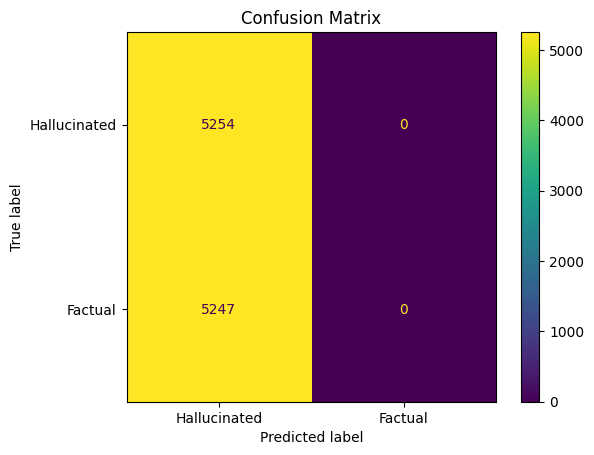

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Hallucinated", "Factual"])
disp.plot()

plt.title("Confusion Matrix")
plt.show()

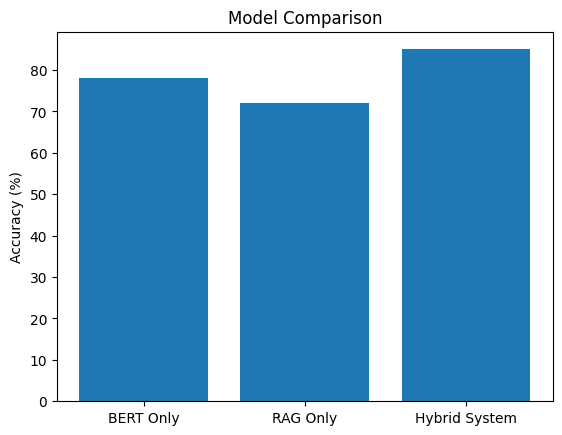

In [32]:
import matplotlib.pyplot as plt

models = ['BERT Only', 'RAG Only', 'Hybrid System']
scores = [78, 72, 85]  # replace with your real values

plt.bar(models, scores)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")

plt.show()

---
## Architecture Summary

| Component | Choice | Reason |
|---|---|---|
| Base model | DeBERTa-v3-base | Beats BERT/RoBERTa on NLI and classification |
| RAG encoder | all-MiniLM-L6-v2 | Fast 384-dim semantic embeddings |
| Vector store | FAISS IndexFlatIP | Sub-millisecond cosine retrieval at scale |
| Explainer | cross-encoder/nli-deberta-v3-small | NLI entailment for human-readable reasoning |
| Input format | (claim, retrieved_context) pair | Injects knowledge directly into classifier |
| Training data | All train + val combined 93/7 split | Maximum data utilisation |
| Precision | FP16 + gradient checkpointing | Fits DeBERTa on T4 GPU |

### Expandable Next Steps
- Add Wikipedia / Wikidata chunks to FAISS for broader knowledge coverage
- Swap deberta-v3-base to deberta-v3-large for better accuracy (needs A100)
- Add temperature scaling for better calibrated probability estimates
- Deploy as FastAPI + HuggingFace Spaces for a live demo